# Verify `honeycomb_hex.py` — Hexagonal-Crop Honeycomb Slab

This notebook verifies that `create_hexagonal_honeycomb_slab` (in `honeycomb_hex.py`)
produces the correct geometry, matching the Lumerical script.

**Key differences from `create_centered_honeycomb_slab`:**
- Uses a **hexagonal region** mask (axial / cube coordinates) instead of a rectangular crop.
- Sublattice A: `y = a*(j*√3/2 − 1/(2√3))`
- Sublattice B: `y = a*(j*√3/2 + 1/(2√3))`


## 1 — Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tidy3d as td

# New hexagonal-crop implementation
from honeycomb_hex import create_hexagonal_honeycomb_slab
# Original rectangular-crop implementation (for comparison)
from honeycomb import create_centered_honeycomb_slab

print("Imports OK")


05:25:30 Pacific Standard Time WARNING: Using canonical configuration directory 
                               at 'C:\Users\xtliang\.config\tidy3d'. Found      
                               legacy directory at '~/.tidy3d', which will be   
                               ignored. Remove it manually or run 'tidy3d config
                               migrate --delete-legacy' to clean up.            

Imports OK


## 2 — Define Parameters
Mirrors the Lumerical script variables: `a`, `R`, `radius`, `z_span`, `material`, `index`.

In [2]:
# ── Parameters (match the Lumerical script variables) ────────────────────────
a       = 1.0     # Lattice constant (um)
R       = 5       # Hexagonal radius in unit-cell repeats
radius  = 0.225   # Disk radius (um)  — corresponds to diameter 0.45 um
z_span  = 0.22    # Slab thickness (um)
n_si    = 3.47    # Refractive index of silicon
material = td.Medium(permittivity=n_si**2)

# Twist parameters for double-layer verification
ANGLE   = 1.5     # Twist angle (degrees)
GAP     = 0.3     # Gap between the two slabs (um)

print(f"lattice constant  a = {a} um")
print(f"hexagonal radius  R = {R}  (total unit cells = {3*R*(R+1)+1})")
print(f"disk radius           = {radius} um")
print(f"slab thickness        = {z_span} um")
print(f"sublattice Δy         = {a/(2*np.sqrt(3)):.6f} um  (= a/(2√3))")


lattice constant  a = 1.0 um
hexagonal radius  R = 5  (total unit cells = 91)
disk radius           = 0.225 um
slab thickness        = 0.22 um
sublattice Δy         = 0.288675 um  (= a/(2√3))


## 3-5 — Hexagonal Filter + Sublattice A & B (NumPy version)
Directly replicates the Lumerical loops so you can audit the geometry without tidy3d.

In [3]:
dy = a / (2.0 * np.sqrt(3))   # = a*sqrt(3)/6 ≈ 0.2887*a

xs_A, ys_A = [], []  # Sublattice A positions
xs_B, ys_B = [], []  # Sublattice B positions

for i in range(-R, R + 1):
    for j in range(-R, R + 1):
        k = -i - j
        # ── Hexagonal mask (exact Lumerical condition) ──────────────────────
        if abs(i) <= R and abs(j) <= R and abs(k) <= R:
            x = a * (i + j / 2.0)
            y_row = a * (j * np.sqrt(3) / 2.0)

            # Sublattice A  (y = a*(j*sqrt(3)/2 - 1/sqrt(3)/2))
            xs_A.append(x)
            ys_A.append(y_row - dy)

            # Sublattice B  (y = a*(j*sqrt(3)/2 + 1/sqrt(3)/2))
            xs_B.append(x)
            ys_B.append(y_row + dy)

xs_A, ys_A = np.array(xs_A), np.array(ys_A)
xs_B, ys_B = np.array(xs_B), np.array(ys_B)

print(f"Unit cells in hexagonal region : {len(xs_A)}")        # = 3R(R+1)+1
print(f"Total disks in one layer       : {len(xs_A)+len(xs_B)}")


Unit cells in hexagonal region : 91
Total disks in one layer       : 182


## 7 — Visualise 2D Cross-Section of the Single Layer
Sublattice A (red) and sublattice B (blue) are coloured differently to verify
the honeycomb pairing.

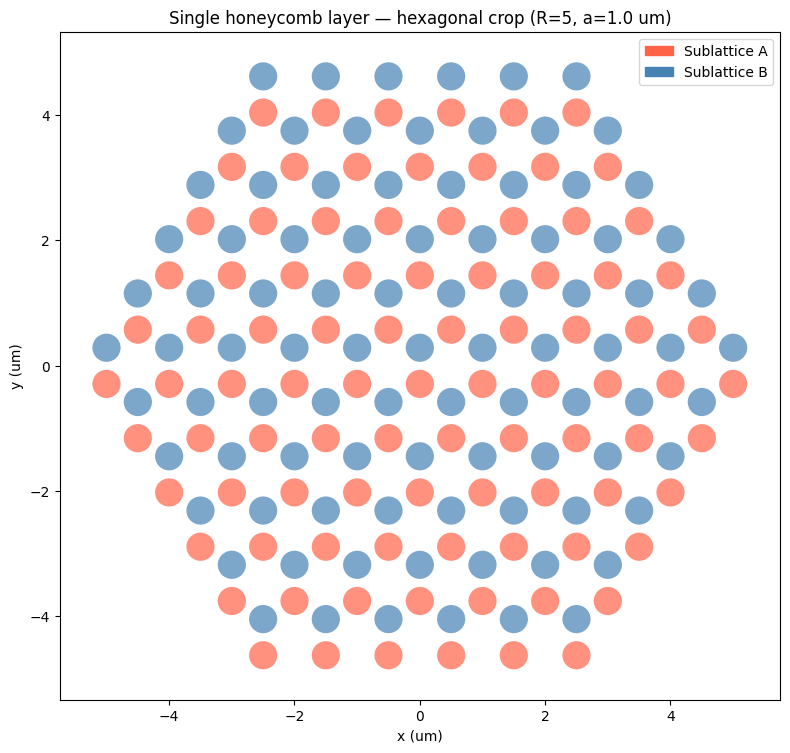

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

for (x, y) in zip(xs_A, ys_A):
    circ = plt.Circle((x, y), radius, color="tomato", alpha=0.7, linewidth=0)
    ax.add_patch(circ)

for (x, y) in zip(xs_B, ys_B):
    circ = plt.Circle((x, y), radius, color="steelblue", alpha=0.7, linewidth=0)
    ax.add_patch(circ)

ax.set_aspect("equal")
ax.autoscale_view()
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title(f"Single honeycomb layer — hexagonal crop (R={R}, a={a} um)")
ax.legend(handles=[
    mpatches.Patch(color="tomato",    label="Sublattice A"),
    mpatches.Patch(color="steelblue", label="Sublattice B"),
])
plt.tight_layout()
plt.show()


## 8 — Verify Sublattice Separation
Each unit cell should have exactly two disks separated by $\Delta y = \dfrac{a}{\sqrt{3}}$.

In [5]:
expected_dy = a / np.sqrt(3)            # distance between the two sublattices
actual_dy   = ys_B - ys_A               # element-wise (same N, same order)

print(f"Expected Δy between sublattice A and B : {expected_dy:.6f} um")
print(f"Actual   Δy (min / max)                : {actual_dy.min():.6f} / {actual_dy.max():.6f} um")

assert np.allclose(actual_dy, expected_dy, atol=1e-10), "Sublattice separation mismatch!"
print("✓  Sublattice separation PASSED")

# Also verify equal x-coordinates for each pair
assert np.allclose(xs_A, xs_B, atol=1e-10), "x-coordinate mismatch between sublattices!"
print("✓  Sublattice x-positions match  PASSED")


Expected Δy between sublattice A and B : 0.577350 um
Actual   Δy (min / max)                : 0.577350 / 0.577350 um
✓  Sublattice separation PASSED
✓  Sublattice x-positions match  PASSED


## 6 — Verify `create_hexagonal_honeycomb_slab` Matches Manual NumPy Calculation
Call the wrapper function and check that every cylinder centre matches the positions computed above.

In [6]:
cyls = create_hexagonal_honeycomb_slab(
    lattice_const=a,
    disk_radius=radius,
    slab_thickness=z_span,
    hex_radius=R,
    twist_angle=0.0,
    material=material,
    centerz=0.0,
)

# Extract cylinder centres from the tidy3d objects
fn_xy = np.array([[c.center[0], c.center[1]] for c in cyls])

# Build the reference set (A first, then B, interleaved by how the loop runs)
ref_xy = np.concatenate([
    np.stack([xs_A, ys_A], axis=1),
    np.stack([xs_B, ys_B], axis=1),
])

# Sort both arrays the same way (by x then y) for comparison
def sort_xy(arr):
    idx = np.lexsort((arr[:, 1], arr[:, 0]))
    return arr[idx]

fn_sorted  = sort_xy(fn_xy)
ref_sorted = sort_xy(ref_xy)

assert fn_sorted.shape == ref_sorted.shape, "Different number of disks!"
assert np.allclose(fn_sorted, ref_sorted, atol=1e-10), "Position mismatch!"

print(f"Total cylinders returned : {len(cyls)}")
print("✓  create_hexagonal_honeycomb_slab positions match manual NumPy calculation  PASSED")


Total cylinders returned : 182
✓  create_hexagonal_honeycomb_slab positions match manual NumPy calculation  PASSED


## Twisted Double-Layer — Top-Down View
Overlay the bottom layer (0°, red) and the top twisted layer (angle = `ANGLE`°, blue).

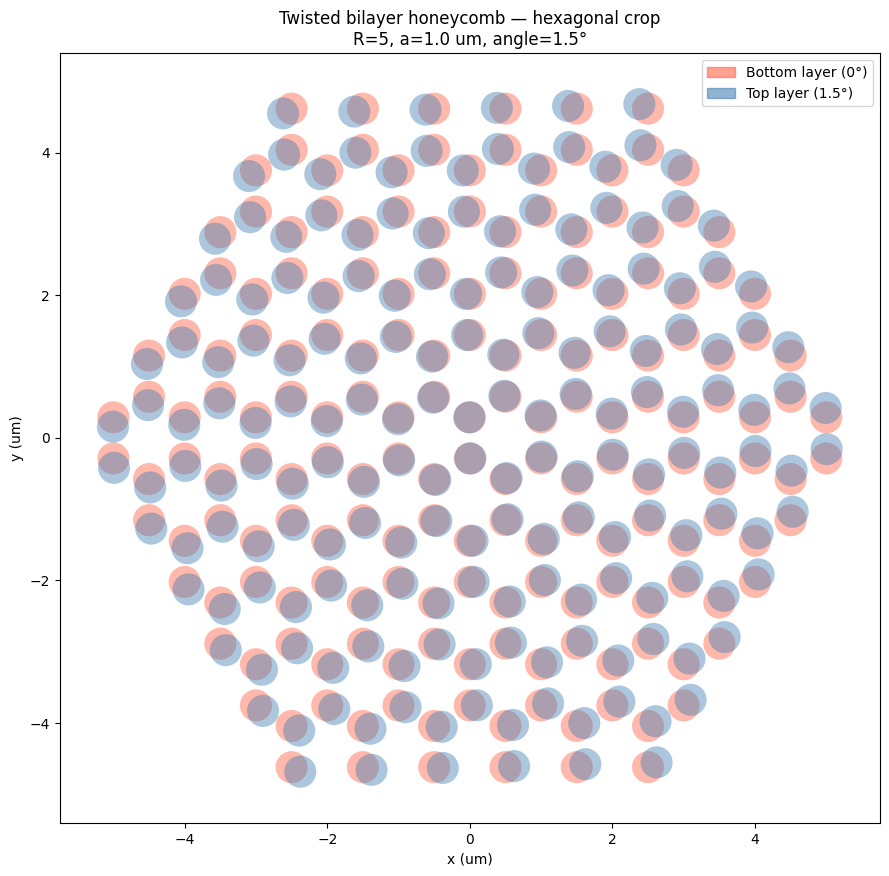

Bottom layer : 182 disks
Top    layer : 182 disks


In [7]:
cyls_bottom = create_hexagonal_honeycomb_slab(
    lattice_const=a, disk_radius=radius, slab_thickness=z_span,
    hex_radius=R, twist_angle=0.0, material=material, centerz=0.0,
)
cyls_top = create_hexagonal_honeycomb_slab(
    lattice_const=a, disk_radius=radius, slab_thickness=z_span,
    hex_radius=R, twist_angle=ANGLE, material=material, centerz=GAP + z_span,
)

fig, ax = plt.subplots(figsize=(9, 9))

for c in cyls_bottom:
    ax.add_patch(plt.Circle((c.center[0], c.center[1]), c.radius,
                             color="tomato", alpha=0.45, linewidth=0))

for c in cyls_top:
    ax.add_patch(plt.Circle((c.center[0], c.center[1]), c.radius,
                             color="steelblue", alpha=0.45, linewidth=0))

ax.set_aspect("equal")
ax.autoscale_view()
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title(f"Twisted bilayer honeycomb — hexagonal crop\n"
             f"R={R}, a={a} um, angle={ANGLE}°")
ax.legend(handles=[
    mpatches.Patch(color="tomato",    alpha=0.6, label=f"Bottom layer (0°)"),
    mpatches.Patch(color="steelblue", alpha=0.6, label=f"Top layer ({ANGLE}°)"),
])
plt.tight_layout()
plt.show()

print(f"Bottom layer : {len(cyls_bottom)} disks")
print(f"Top    layer : {len(cyls_top)} disks")


## 9 — Compare Against `create_centered_honeycomb_slab` (Rectangular Crop)
Plot both methods side-by-side on the **inner** hexagonal region to highlight the
boundary difference: the hexagonal method produces a clean hexagonal boundary,
while the rectangular method produces a square boundary.

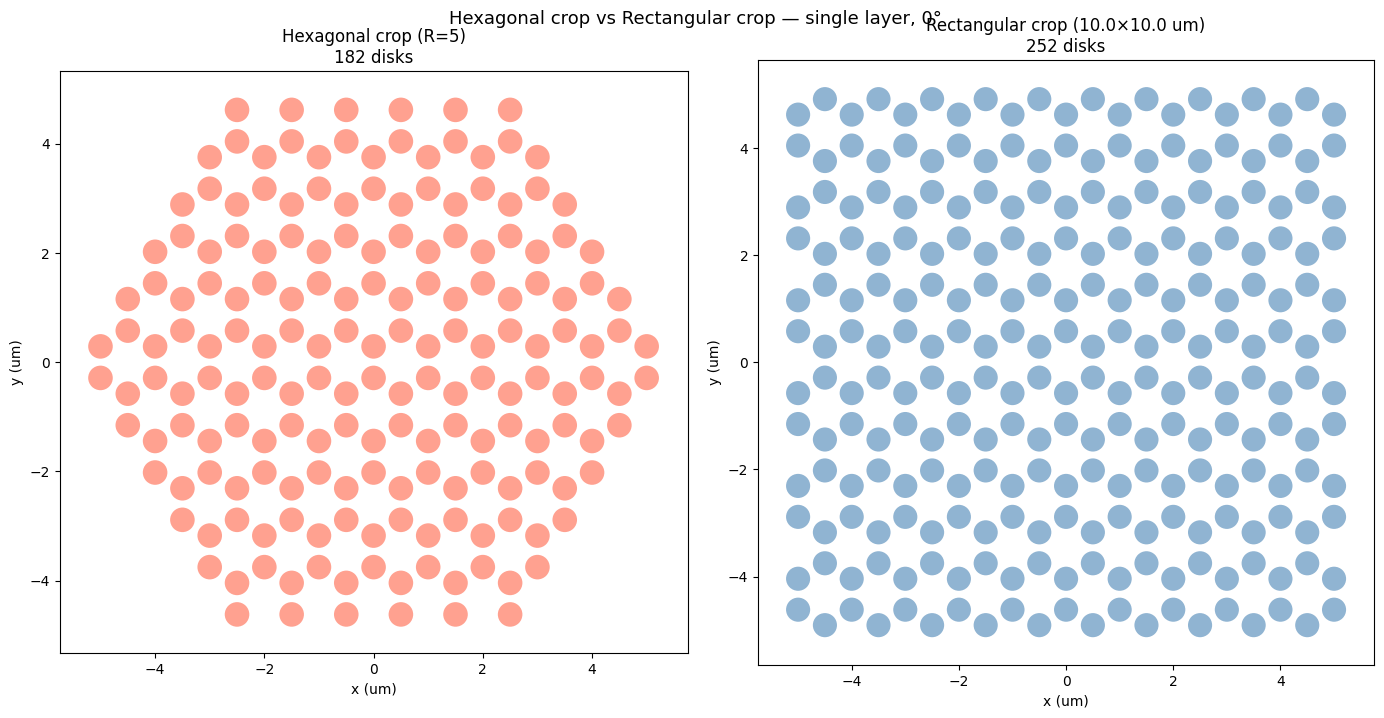

Hexagonal crop : 182 disks
Rectangular crop : 252 disks


In [8]:
# Hexagonal crop — new method
cyls_hex = create_hexagonal_honeycomb_slab(
    lattice_const=a, disk_radius=radius, slab_thickness=z_span,
    hex_radius=R, twist_angle=0.0, material=material, centerz=0.0,
)

# Rectangular crop — original method (domain_size chosen to roughly match hex region)
domain_L = R * a * 2.0   # approximate equivalent side length
cyls_rect = create_centered_honeycomb_slab(
    lattice_const=a,
    disk_diameter=radius * 2,
    slab_thickness=z_span,
    twist_angle=0.0,
    domain_size=(domain_L, domain_L),
    material=material,
    centerz=0.0,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax_i, (cyls, title, color) in zip(axes, [
    (cyls_hex,  f"Hexagonal crop (R={R})\n{len(cyls_hex)} disks",  "tomato"),
    (cyls_rect, f"Rectangular crop ({domain_L}×{domain_L} um)\n{len(cyls_rect)} disks", "steelblue"),
]):
    for c in cyls:
        ax_i.add_patch(plt.Circle((c.center[0], c.center[1]), c.radius,
                                   color=color, alpha=0.6, linewidth=0))
    ax_i.set_aspect("equal")
    ax_i.autoscale_view()
    ax_i.set_title(title)
    ax_i.set_xlabel("x (um)")
    ax_i.set_ylabel("y (um)")

plt.suptitle("Hexagonal crop vs Rectangular crop — single layer, 0°", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Hexagonal crop : {len(cyls_hex)} disks")
print(f"Rectangular crop : {len(cyls_rect)} disks")


## Tidy3D Simulation Plot — Cross-sections at z of each slab
Build a minimal `td.Simulation` with the twisted bilayer and use `sim.plot()` to
view x-y cross-sections at the mid-plane of each layer, plus an x-z side view.

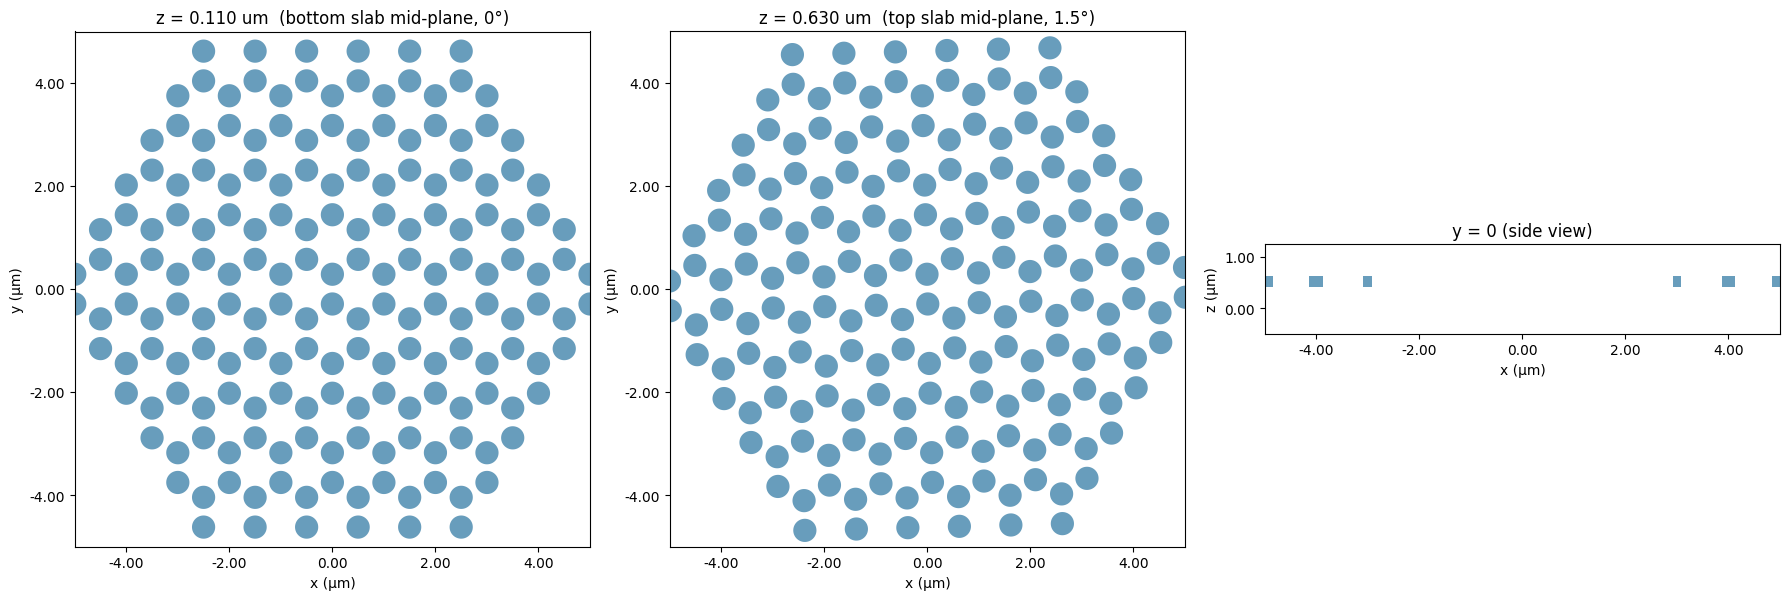

In [9]:
freq0 = td.C_0 / 1.0   # reference wavelength = 1 um → freq in THz

lx = (R * a) * 2.0
ly = lx
lz = z_span * 2 + GAP + 1.0

# Build a single td.Structure from all cylinders
all_geom = td.GeometryGroup(geometries=cyls_bottom + cyls_top)
structure = td.Structure(geometry=all_geom, medium=material)

sim = td.Simulation(
    center=(0, 0, (z_span * 2 + GAP) / 2),
    size=(lx, ly, lz),
    structures=[structure],
    sources=[],
    monitors=[],
    run_time=1e-13,
    grid_spec=td.GridSpec.uniform(dl=a / 5),
    boundary_spec=td.BoundarySpec.all_sides(td.Periodic()),
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# x-y at mid-plane of bottom slab
sim.plot(z=z_span / 2, ax=axes[0])
axes[0].set_xlim(-lx / 2, lx / 2)
axes[0].set_ylim(-ly / 2, ly / 2)
axes[0].set_title(f"z = {z_span/2:.3f} um  (bottom slab mid-plane, 0°)")

# x-y at mid-plane of top slab
z_top_mid = GAP + z_span + z_span / 2
sim.plot(z=z_top_mid, ax=axes[1])
axes[1].set_xlim(-lx / 2, lx / 2)
axes[1].set_ylim(-ly / 2, ly / 2)
axes[1].set_title(f"z = {z_top_mid:.3f} um  (top slab mid-plane, {ANGLE}°)")

# x-z side view
sim.plot(y=0, ax=axes[2])
axes[2].set_title("y = 0 (side view)")

plt.tight_layout()
plt.show()
